# 03 – Rule-Based Anomaly Labels 

## Three rule categories (after revision against full-data feedback)

v1 of these rules was set with literature-default thresholds (e.g. `|accel| > 3 m/s²`, `dist < 3 m`). On the 10k sample this gave a 9% per-row flag rate; on the full ~2M-row dataset it became clear that those thresholds were detecting normal junction behaviour (braking-to-merge, dense traffic) rather than anomalies. The rules below are the revised versions:

1. **Sustained hard braking** – at least 2 of the last 3 consecutive points have `acceleration_ms2 < -3 m/s²`, on non-imputed rows. Sustainment filters single-frame spikes (often tracker artefacts) and normal merge braking. Grounded in surrogate-safety harsh-braking literature, with sustainment from event-detection practice.
2. **Path deviation extremes** – per-cluster Q99.5 of `deviation_m`. Tighter than v1's Q99 because Q99 at full scale captures normal corridor-edge driving.
3. **Close-conflict events** – proximity (0.5-3 m, excluding tracker glitches) *combined with* simultaneous hard braking. Proximity alone is normal at a dense junction; only the reaction (braking) elevates it to a conflict event.
4. **Anomalous stop in zone** – `Speed_ms < 1.0` AND `in_conflict_zone` AND `time_in_zone_running_s > 5 s`. Unchanged from v1, already rare and well-grounded (Pramanik 2022).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Parameters

In [2]:
IN_PATH = Path('features_full.parquet')  
OUT_PATH = Path('features_labelled.parquet')

# Kinematic
HARD_BRAKE_MS2 = -3.0     # m/s²; below = hard brake
ANOM_STOP_SPEED_MS = 1.0  # m/s; below = effectively stopped
ANOM_STOP_DWELL_S = 5.0   # seconds in zone before a stop counts as anomalous

# Path deviation
PATH_DEV_PERCENTILE = 99.5  # top 0.5% within each cluster

# Close conflict
TRACKER_GLITCH_M = 0.5    # below this is treated as a tracker artefact, not a conflict
CLOSE_CONFLICT_M = 3.0    # upper bound for a close-conflict event

## 2. Load features

In [3]:
df = pd.read_parquet(IN_PATH)
print(f'Rows: {len(df):,}')
print(f'Vehicles: {df["ID"].nunique():,}')

# The deviation_m column was computed against a cluster median in notebook 02. To compute per-cluster percentiles we need
# the cluster ID for each row. The cluster was defined by (entry_sector, exit_sector) of the
# trajectory. It is recomputed here so notebook 03 is self-contained.
from conflict_zone_polygon import CONFLICT_ZONE_POLYGON
centre_x = np.mean([p[0] for p in CONFLICT_ZONE_POLYGON])
centre_y = np.mean([p[1] for p in CONFLICT_ZONE_POLYGON])
# Use the same centre as notebook 02: (5, -15). The mean of the polygon may differ slightly;
# we keep notebook 02's value for consistency.
CENTRE_XY = (5.0, -15.0)
N_SECTORS = 8

def sector_of(x, y, n=N_SECTORS):
    a = np.arctan2(y - CENTRE_XY[1], x - CENTRE_XY[0])
    return ((a + 2*np.pi) % (2*np.pi) / (2*np.pi/n)).astype(int)

fl = df.groupby('ID', sort=False).agg(
    x_first=('X', 'first'), y_first=('Y', 'first'),
    x_last=('X', 'last'),   y_last=('Y', 'last'),
)
fl['entry'] = sector_of(fl['x_first'].to_numpy(), fl['y_first'].to_numpy())
fl['exit']  = sector_of(fl['x_last'].to_numpy(),  fl['y_last'].to_numpy())
fl['cluster'] = list(zip(fl['entry'], fl['exit']))
df = df.merge(fl[['cluster']], on='ID', how='left')
print(f'Cluster column attached. Unique clusters in data: {df["cluster"].nunique()}')

Rows: 1,372,369
Vehicles: 46,578
Cluster column attached. Unique clusters in data: 46


## 3. Rule 1 – Kinematic extremes (sustained)

After running v1 of these rules on the full ~2M-row dataset, what was found was that single-point threshold rules fire on ~9% of rows, including most points along the entire approach to the junction. That is not anomalous, that is normal braking-to-merge behaviour. An anomaly must persist for more than one frame.

Revised rules:
- **Sustained hard braking**: at least 2 of the last 3 consecutive points have `acceleration_ms2 < -3 m/s²`, on non-imputed rows. A single spike (often a tracker artefact) is no longer enough.
- **Aggressive acceleration is dropped as a stand-alone rule.** It captures normal departures from the merge, but no literature ground for treating it as anomalous (vs. hard braking, which directly links to collision risk).
- **Anomalous stop**: unchanged (already strict and rare).

In [4]:
df = df.sort_values(['ID', 'Time']).reset_index(drop=True)
g = df.groupby('ID', sort=False)

accel_trust = ~df['accel_from_estimated'].fillna(False)
df['_hb_pointwise'] = accel_trust & (df['acceleration_ms2'] < HARD_BRAKE_MS2)
# At each row, how many of the last 3 consecutive rows (within same vehicle) were hard-brake?
df['_hb_recent_3'] = g['_hb_pointwise'].transform(lambda s: s.rolling(3, min_periods=1).sum())
df['rule_hard_brake'] = df['_hb_recent_3'] >= 2
df = df.drop(columns=['_hb_pointwise', '_hb_recent_3'])

df['rule_anomalous_stop'] = (
    (df['Speed_ms'] < ANOM_STOP_SPEED_MS) &
    df['in_conflict_zone'].fillna(False) &
    (df['time_in_zone_running_s'] > ANOM_STOP_DWELL_S)
)

for r in ['rule_hard_brake', 'rule_anomalous_stop']:
    n = df[r].sum()
    print(f'  {r}: {n:,} rows ({n/len(df)*100:.2f}%)')

  rule_hard_brake: 21,948 rows (1.60%)
  rule_anomalous_stop: 2,167 rows (0.16%)


## 4. Rule 2 – Path deviation extremes (per-cluster Q99.5)

Top 0.5% of `deviation_m` *within each cluster*. Per-cluster avoids the confound that some clusters (e.g. straight-through corridors) have inherently smaller spreads than others (e.g. turning corridors). Q99.5 rather than Q99 because at full scale even Q99 fires too broadly along normal corridor edges.

In [5]:
# Compute the per-cluster Q99 threshold using only rows where deviation_m is defined.
cluster_q = (
    df.dropna(subset=['deviation_m'])
      .groupby('cluster')['deviation_m']
      .quantile(PATH_DEV_PERCENTILE / 100)
      .rename('dev_threshold')
)
df = df.merge(cluster_q, on='cluster', how='left')

df['rule_path_deviation'] = (
    df['deviation_m'].notna() &
    df['dev_threshold'].notna() &
    (df['deviation_m'] > df['dev_threshold'])
)

print(f'Per-cluster Q{PATH_DEV_PERCENTILE} thresholds (m):')
print(cluster_q.round(2).to_string())
print(f'\nTotal rule_path_deviation: {df["rule_path_deviation"].sum():,} rows ({df["rule_path_deviation"].mean()*100:.2f}%)')

Per-cluster Q99.5 thresholds (m):
cluster
(0, 7)    14.37
(1, 7)    13.27
(2, 0)     5.42
(2, 1)    10.34
(2, 2)    29.00
(2, 6)     6.00
(2, 7)     6.83
(3, 2)     8.81
(4, 2)    13.92
(4, 3)    13.39
(4, 4)     7.26
(4, 5)    11.38
(4, 6)     6.30
(4, 7)     6.22
(5, 2)     6.91
(5, 3)     6.80
(5, 4)    18.74
(5, 5)    11.10
(5, 6)     7.27
(5, 7)     9.76
(6, 6)    17.85
(6, 7)     9.74
(7, 6)    26.81
(7, 7)    13.31

Total rule_path_deviation: 6,853 rows (0.50%)


## 5. Rule 3 — Close-conflict events (proximity + driver reaction)

Spatial proximity alone is not anomaly, at a dense junction, vehicles are routinely close to each other (the v1 proximity-only rule fired on ~76,000 rows in the full dataset, corresponding to normal merge-zone density). A genuine close-conflict event requires both (a) proximity and (b) evidence of a driver reaction, here proxied by the close vehicle is hard-braking at the same moment.

`rule_close_proximity` is kept as diagnostic but only `rule_close_conflict` is treated as anomalous.

The lower bound at 0.5 m excludes tracker glitches (two IDs sharing an exact position, empirically validated as a data artefact).

In [6]:
in_glitch_range  = df['dist_nearest_m'] < TRACKER_GLITCH_M
in_proximity = (df['dist_nearest_m'] >= TRACKER_GLITCH_M) & (df['dist_nearest_m'] < CLOSE_CONFLICT_M)

df['rule_close_proximity'] = in_proximity.fillna(False)  # diagnostic only
df['rule_close_conflict'] = df['rule_close_proximity'] & df['rule_hard_brake']

print(f'Tracker-glitch rows (excluded): {in_glitch_range.sum():,}')
print(f'rule_close_proximity (diagnostic): {df["rule_close_proximity"].sum():,} rows ({df["rule_close_proximity"].mean()*100:.2f}%)')
print(f'rule_close_conflict (proximity + hard brake): {df["rule_close_conflict"].sum():,} rows ({df["rule_close_conflict"].mean()*100:.2f}%)')

Tracker-glitch rows (excluded): 35,767
rule_close_proximity (diagnostic): 75,712 rows (5.52%)
rule_close_conflict (proximity + hard brake): 1,847 rows (0.13%)


## 6. Aggregate flags

In [7]:
rule_cols = ['rule_hard_brake', 'rule_anomalous_stop',
             'rule_path_deviation', 'rule_close_conflict']

df['rule_any'] = df[rule_cols].any(axis=1)
df['rule_count'] = df[rule_cols].sum(axis=1)  # how many rules each row triggers

# Per-trajectory aggregate: any row of this trajectory flagged.
traj_flag = df.groupby('ID')['rule_any'].any().rename('is_anomalous_trajectory')
df = df.merge(traj_flag, on='ID', how='left')

print(f'rule_any: {df["rule_any"].sum():,} rows ({df["rule_any"].mean()*100:.2f}%)')
print(f'Anomalous trajectories: {traj_flag.sum():,} / {len(traj_flag):,} ({traj_flag.mean()*100:.1f}%)')
print(f'\nRule-count distribution (how many rules per row):')
print(df['rule_count'].value_counts().sort_index().to_string())

rule_any: 30,852 rows (2.25%)
Anomalous trajectories: 12,704 / 46,578 (27.3%)

Rule-count distribution (how many rules per row):
rule_count
0    1341517
1      28897
2       1947
3          8


## 7. Summary table and overlap matrix

How often do rules co-occur? High overlap means rules are redundant; near-zero overlap means they capture genuinely different anomaly types.

In [8]:
# Pairwise overlap: P(rule_j | rule_i) — i.e. given rule_i fires, what fraction also fire rule_j?
overlap = pd.DataFrame(index=rule_cols, columns=rule_cols, dtype=float)
for ri in rule_cols:
    n_i = df[ri].sum()
    for rj in rule_cols:
        both = (df[ri] & df[rj]).sum()
        overlap.loc[ri, rj] = both / n_i if n_i > 0 else np.nan
print('Overlap matrix: rows = condition rule, columns = co-firing rule.')
print('Cell (i, j) = P(rule_j fires | rule_i fires).')
print(overlap.round(3))

Overlap matrix: rows = condition rule, columns = co-firing rule.
Cell (i, j) = P(rule_j fires | rule_i fires).
                     rule_hard_brake  rule_anomalous_stop  \
rule_hard_brake                1.000                  0.0   
rule_anomalous_stop            0.001                  1.0   
rule_path_deviation            0.016                  0.0   
rule_close_conflict            1.000                  0.0   

                     rule_path_deviation  rule_close_conflict  
rule_hard_brake                    0.005                0.084  
rule_anomalous_stop                0.000                0.000  
rule_path_deviation                1.000                0.001  
rule_close_conflict                0.004                1.000  


## 8. Plot anomalous events on the map

Visual check: do the rule-flagged rows cluster in places that make physical sense?

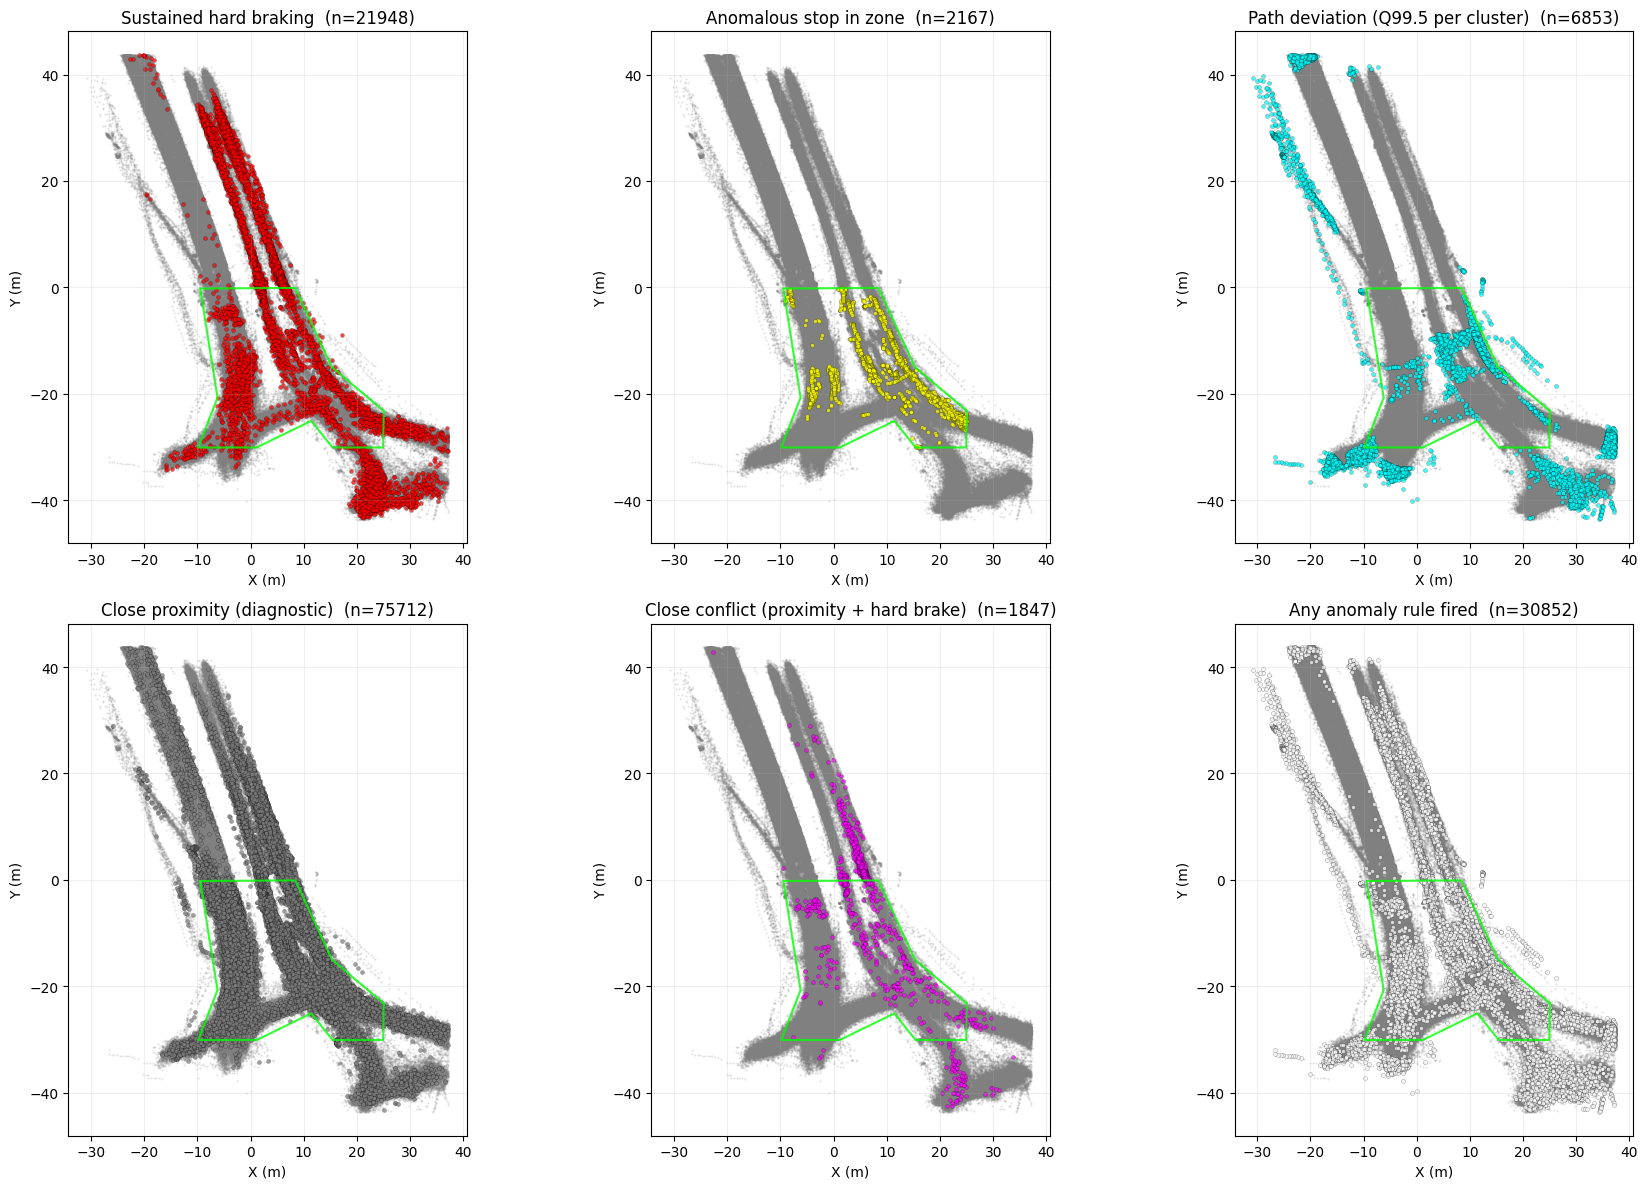

In [9]:
from conflict_zone_polygon import CONFLICT_ZONE_POLYGON
pxy = np.array(CONFLICT_ZONE_POLYGON)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

plot_specs = [
    ('rule_hard_brake', 'Sustained hard braking', 'red'),
    ('rule_anomalous_stop', 'Anomalous stop in zone', 'yellow'),
    ('rule_path_deviation', 'Path deviation (Q99.5 per cluster)', 'cyan'),
    ('rule_close_proximity', 'Close proximity (diagnostic)', 'gray'),
    ('rule_close_conflict', 'Close conflict (proximity + hard brake)', 'magenta'),
    ('rule_any', 'Any anomaly rule fired', 'white'),
]

for ax, (col, title, c) in zip(axes, plot_specs):
    # Background: all positions in grey
    ax.scatter(df['X'], df['Y'], s=0.3, c='gray', alpha=0.2)
    # Flagged positions
    flagged = df[df[col]]
    ax.scatter(flagged['X'], flagged['Y'], s=8, c=c, alpha=0.7, edgecolors='black', linewidths=0.2)
    # Polygon
    ax.plot(np.append(pxy[:, 0], pxy[0, 0]), np.append(pxy[:, 1], pxy[0, 1]),
            '-', color='lime', linewidth=1.5, alpha=0.8)
    ax.set_title(f'{title}  (n={int(df[col].sum())})')
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('rule_labels_map.png', dpi=110)
plt.show()

## 9. Save the labelled features file

In [10]:
df.to_parquet(OUT_PATH, index=False)
print(f'Saved {len(df):,} rows × {len(df.columns)} columns to {OUT_PATH}')
print(f'\nRule columns added: {rule_cols + ["rule_any", "rule_count", "is_anomalous_trajectory", "rule_close_conflict_brake"]}')

Saved 1,372,369 rows × 49 columns to features_labelled.parquet

Rule columns added: ['rule_hard_brake', 'rule_anomalous_stop', 'rule_path_deviation', 'rule_close_conflict', 'rule_any', 'rule_count', 'is_anomalous_trajectory', 'rule_close_conflict_brake']
